In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL")
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

### Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`).
2. Clean the data: handle missing values, examine distributions, and note any anomalies.
3. Select the numeric features and scale them with `StandardScaler`.
4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.
5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**.
7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.
8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?

In [14]:
df = sns.load_dataset("penguins")

In [15]:
df_clean = df.dropna().reset_index(drop=True)

In [16]:
features_numeric = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[features_numeric]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

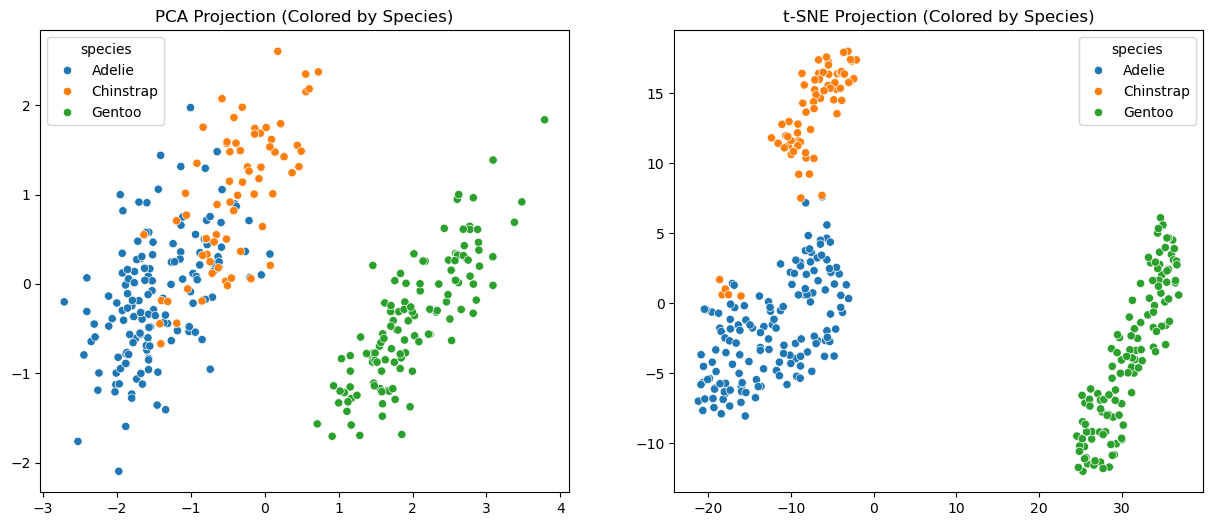

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['species'], ax=ax[0])
ax[0].set_title('PCA Projection (Colored by Species)')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_clean['species'], ax=ax[1])
ax[1].set_title('t-SNE Projection (Colored by Species)')
plt.show()

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

dbscan1 = DBSCAN(eps=0.5, min_samples=5)
db1_labels = dbscan1.fit_predict(X_scaled)

dbscan2 = DBSCAN(eps=1.0, min_samples=5)
db2_labels = dbscan2.fit_predict(X_scaled)

def get_dbscan_score(labels, data):
    if len(set(labels)) > 1:
        return silhouette_score(data, labels)
    return "N/A (only 1 cluster found)"

print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"DBSCAN (eps=0.5) Silhouette Score: {get_dbscan_score(db1_labels, X_scaled)}")
print(f"DBSCAN (eps=1.0) Silhouette Score: {get_dbscan_score(db2_labels, X_scaled)}")

K-Means Silhouette Score: 0.4462
DBSCAN (eps=0.5) Silhouette Score: 0.25157063623102277
DBSCAN (eps=1.0) Silhouette Score: 0.46691828883556735


Adjusted Rand Index (ARI): 0.6506
Normalized Mutual Information (NMI): 0.7600


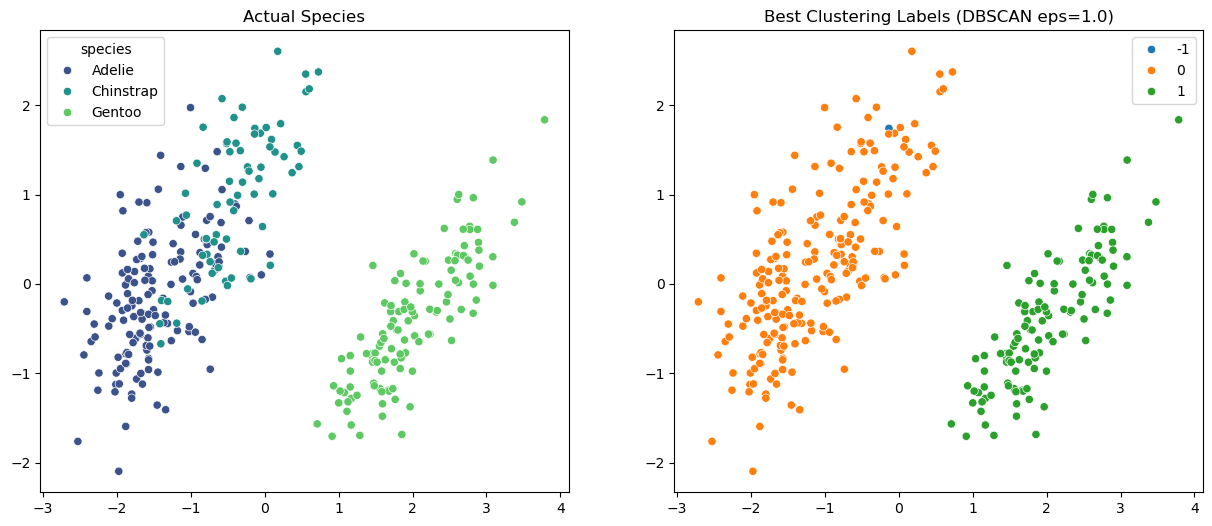

In [19]:
best_labels = db2_labels 

ari = adjusted_rand_score(df_clean['species'], best_labels)
nmi = normalized_mutual_info_score(df_clean['species'], best_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['species'], ax=ax[0], palette='viridis')
ax[0].set_title('Actual Species')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_labels, ax=ax[1], palette='tab10')
ax[1].set_title('Best Clustering Labels (DBSCAN eps=1.0)')

plt.show()

> **Task 1 Summary: Unsupervised Exploration**
> 
> In this task, we explored the underlying structure of the Palmer Penguins dataset using dimensionality reduction and clustering.
> * **Performance:** PCA and t-SNE both revealed two primary clusters. One cluster is composed almost entirely of the **Gentoo** species, while the second is a mixture of **Adelie** and **Chinstrap**.
> * **Clustering Results:** DBSCAN with $eps=1.0$ achieved a silhouette score of **0.4669**, outperforming K-Means. However, the Adjusted Rand Index (ARI) of **0.6506** shows that while the clustering is meaningful, it does not perfectly map to the biological species.
> * **Successes & Failures:** The unsupervised methods successfully recovered the Gentoo species structure due to its distinct physical dimensions. They failed to differentiate between Adelie and Chinstrap, which overlap significantly in the feature space. This highlights the necessity for supervised learning to achieve precise classification.

In [20]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.
2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).
3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.
4. Select the best model based on F1 score.
5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV.
6. Report the best parameters, best CV score, and compare with the default model performance.

In [21]:
df_supervised = df.dropna().copy()
X_sup = df_supervised.drop('species', axis=1)
y_sup = df_supervised['species']

In [22]:
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [23]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    cv_results = cross_validate(pipeline, X_sup, y_sup, cv=skf, scoring=scoring)
    results[name] = {k: np.mean(v) for k, v in cv_results.items()}

results_df = pd.DataFrame(results).T
print(results_df[['test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']])

                    test_accuracy  test_precision_macro  test_recall_macro  \
LogisticRegression        0.99403              0.995833           0.989744   
RandomForest              0.99100              0.988643           0.990274   
SVC                       0.99403              0.995833           0.989744   

                    test_f1_macro  
LogisticRegression       0.992294  
RandomForest             0.989133  
SVC                      0.992294  


In [24]:
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('classifier', SVC(probability=True, random_state=42))])

In [25]:
grid_search = GridSearchCV(best_pipeline, param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_sup, y_sup)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

default_f1 = results['SVC']['test_f1_macro']
print(f"Improvement over default: {grid_search.best_score_ - default_f1:.4f}")

Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV F1 Score: 0.9962
Improvement over default: 0.0039


> **Task 2 Summary: Supervised Model Pipeline**
> 
> In this phase, we developed a supervised classification pipeline to predict penguin species.
> * **Preprocessing:** A `ColumnTransformer` was implemented to handle the heterogeneous dataset, applying `StandardScaler` to numeric features (bill dimensions, flipper length, and body mass) and `OneHotEncoder` to categorical variables (island and sex).
> * **Model Selection:** We compared **Logistic Regression**, **Random Forest**, and **Support Vector Classification (SVC)** using stratified 5-fold cross-validation. Both Logistic Regression and SVC demonstrated superior initial performance with an F1-macro score of approximately 0.9923.
> * **Optimization:** The SVC model was chosen for further refinement. Through `GridSearchCV`, we identified the optimal parameters: a linear kernel with $C=0.1$. This optimization improved the F1-macro score to **0.9962**, indicating a highly robust model with excellent class separation.

### Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).
2. Print the full **classification report**.
3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`.
4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)
5. Plot **learning curves** (training size from 10% to 100%).
6. Compute **permutation importances** on the test set and plot the top features.
7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?

### Task 4 — Model Deployment Prototype

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`.
2. Create an **`app.py`** file with a Flask `/predict` endpoint that:
   - Loads the serialized pipeline.
   - Accepts JSON input with penguin measurements (numeric and categorical features).
   - Returns the predicted species and class probabilities.
   - Includes basic input validation.
3. Also add a `/health` endpoint.
4. Test the API from your notebook:
   - Send a valid request with sample penguin measurements.
   - Send an invalid request and verify error handling.
5. Document the API in a markdown cell: endpoint, expected input format, example request/response.